# ECG: heart rate from raw samples

This notebook takes a raw electrocardiogram and ends with a beats-per-minute reading, using nothing but `convolinear`'s fluent API: **load -> inspect the spectrum -> bandpass -> detect peaks -> BPM**.

The data is `scipy.datasets.electrocardiogram()`: five minutes of a real ECG sampled at 360 Hz, an excerpt (19:35 to 24:35) of record 208 from the MIT-BIH Arrhythmia Database on PhysioNet. It is a deliberately awkward recording - it contains premature ventricular contractions and several stretches of movement artifact - which makes it a far more honest test than a clean synthetic trace.

The first call downloads roughly 1 MB via `pooch` and caches it locally; later calls are offline.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.datasets import electrocardiogram

from convolinear import Signal

ecg = Signal(electrocardiogram(), sample_rate=360.0)
ecg

Signal(samples=108000, sample_rate=360 Hz, duration=300.000 s)

A `Signal` knows its own duration, so nothing here needs a sample count. Let's look at ten seconds of it. `trim` takes **seconds**, not indices.

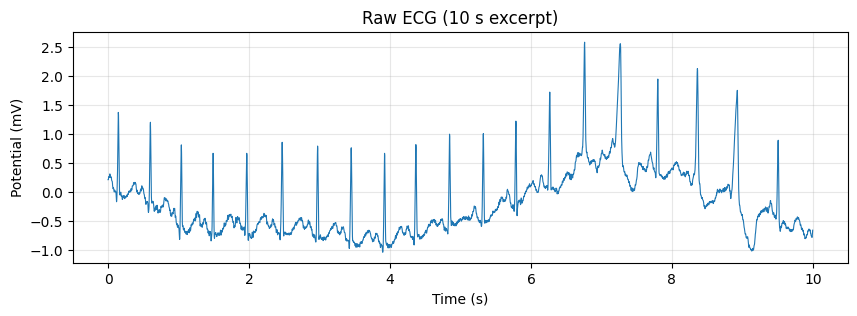

In [2]:
ecg.trim(9, 19).plot(
    title="Raw ECG (10 s excerpt)",
    ylabel="Potential (mV)",
)
plt.show()

The QRS complexes - the tall spikes, one per heartbeat - are already visible. But the baseline drifts up and down, which will defeat any fixed-height peak detector. Before filtering blind, let's see what is actually in the signal.

A single Fast Fourier Transform of a noisy 108,000-sample record is a poor tool here: its variance doesn't shrink as the record gets longer. `psd()` uses Welch's method instead, averaging overlapping windowed segments into a much stabler estimate.

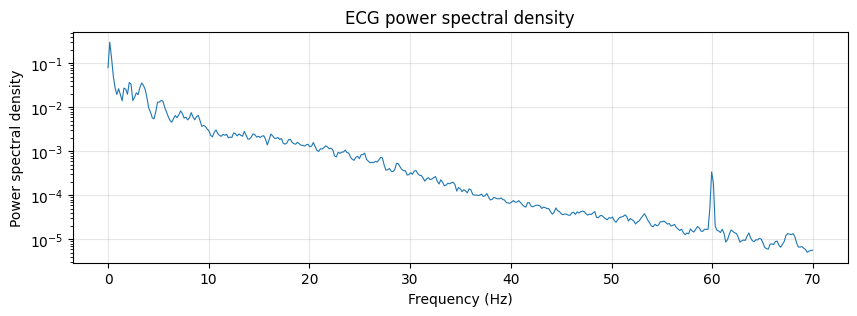

In [3]:
ecg.psd(segment_length=2048).plot(
    max_freq=70,
    title="ECG power spectral density",
)
plt.show()

Two contaminants stand out, and they bracket the signal we want:

- **Baseline wander** - the huge power below ~0.5 Hz. This is respiration and electrode movement, not cardiac activity. It is what makes the trace drift.
- **Mains hum** - the narrow spike near 60 Hz, from the electrical supply.

The QRS complex (the ECG signal characterising ventricular contraction) itself is a sharp, brief deflection, and its energy sits in a band roughly between 5 and 15 Hz. So a bandpass filter across that range should suppress both problems at once and distinguish the beats from a flat baseline. That 5-15 Hz choice is the standard QRS-emphasis band used by classic beat detectors.

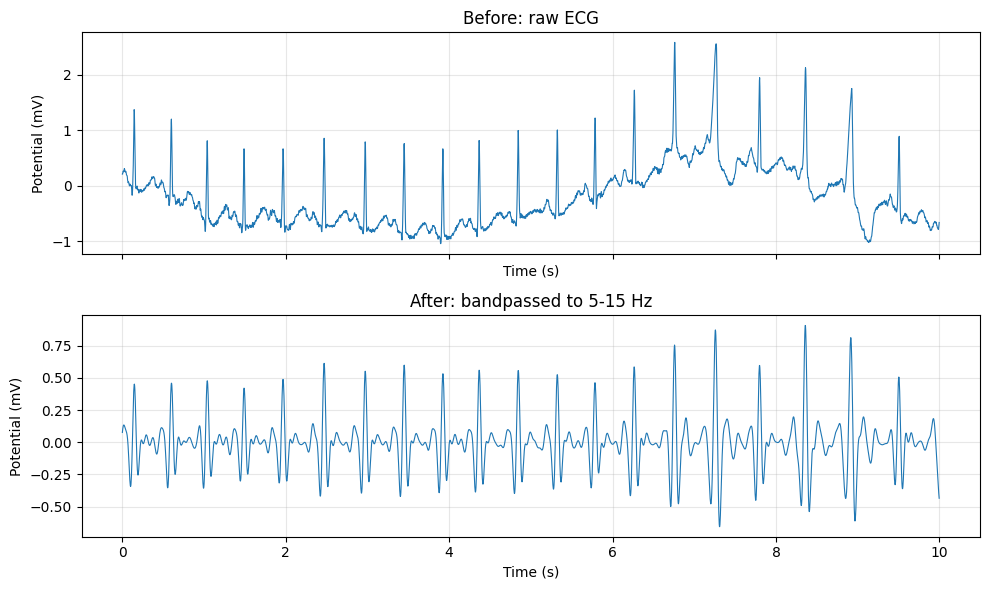

In [4]:
beats = ecg.bandpass(5, 15)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ecg.trim(9, 19).plot(title="Before: raw ECG", ylabel="Potential (mV)", ax=ax1)
beats.trim(9, 19).plot(title="After: bandpassed to 5-15 Hz", ylabel="Potential (mV)", ax=ax2)
plt.tight_layout()
plt.show()

The drift is gone and the baseline is flat, which means a height threshold is now meaningful.

`find_peaks` takes both a minimum height and a minimum spacing in **seconds**. `min_distance=0.35` encodes a physiological fact: no adult heart beats more than ~170 times a minute, so two peaks closer than 0.35 s are the same beat detected twice.

Choosing `min_height` needs a little care. R-peak amplitude varies a lot across this record, so a threshold set as a fraction of the single largest peak has to be generous - a quarter of it works here.
It is worth seeing why the stricter choice fails, below are the results for different `min_height` values.

In [5]:
for fraction in (0.6, 0.5, 0.4, 0.25):
    found = beats.find_peaks(min_height=fraction * beats.data.max(), min_distance=0.35)
    print(
        f"min_height = {fraction:.2f} x max -> {len(found):3d} beats "
        f"({60 * len(found) / ecg.duration:5.1f} bpm overall)"
    )

min_height = 0.60 x max -> 191 beats ( 38.2 bpm overall)
min_height = 0.50 x max -> 381 beats ( 76.2 bpm overall)
min_height = 0.40 x max -> 422 beats ( 84.4 bpm overall)
min_height = 0.25 x max -> 491 beats ( 98.2 bpm overall)


A threshold at 60% of the maximum finds only 191 beats in five minutes - it silently drops more than half of them, and the ~38 bpm that implies would look like a plausible resting heart rate for an athlete if you never questioned it. The count climbs steeply as the threshold drops and then flattens out at `min_height = 0.25 x max`, which is the sign that we are picking up real beats rather than noise. That plateau is the number to trust.

491 beats detected in 300 s


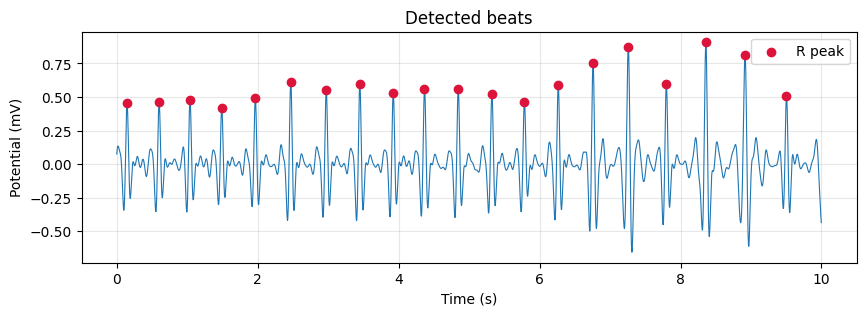

In [6]:
peaks = beats.find_peaks(min_height=0.25 * beats.data.max(), min_distance=0.35)
print(f"{len(peaks)} beats detected in {ecg.duration:.0f} s")

ax = beats.trim(9, 19).plot(title="Detected beats", ylabel="Potential (mV)")
window = (peaks.times >= 9) & (peaks.times <= 19)
ax.scatter(
    peaks.times[window] - 9, peaks.heights[window], color="crimson", zorder=3, label="R peak"
)
ax.legend()
plt.show()

`PeakResult` carries `times` and `heights`, and unpacks like a tuple (`times, heights = peaks`). Note the scatter subtracts the 9 s offset, because `trim` restarts the returned signal's clock at zero while `peaks.times` are measured from the start of the record.

The gap between consecutive beats is all we need for a heart rate.

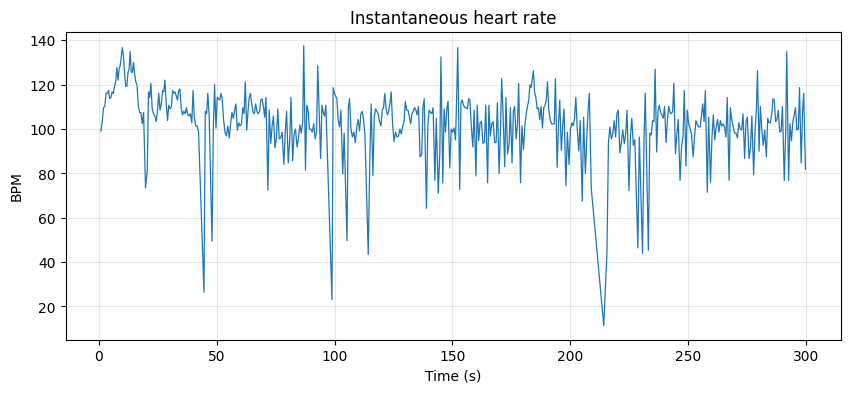

mean    103.0 bpm
median  104.9 bpm
min      11.3 bpm
max     137.6 bpm


In [7]:
bpm = 60.0 / np.diff(peaks.times)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(peaks.times[1:], bpm, lw=0.9)
ax.set_title("Instantaneous heart rate")
ax.set_xlabel("Time (s)")
ax.set_ylabel("BPM")
ax.grid(alpha=0.3)
plt.show()

print(f"mean   {bpm.mean():6.1f} bpm")
print(f"median {np.median(bpm):6.1f} bpm")
print(f"min    {bpm.min():6.1f} bpm")
print(f"max    {bpm.max():6.1f} bpm")

A median around 105 bpm, and about 98 bpm averaged across the whole record - an elevated but entirely plausible rate, and consistent with a recording chosen for its arrhythmia.

The outliers are real, and worth discussing. The spikes toward 140 bpm are the premature ventricular contractions this record is known for: beats that arrive early, shortening the gap. The implausible dips near 11 bpm are not physiology at all - they are the movement artifacts visible in the PSD, stretches where the trace is too corrupted for any beat to clear the threshold, so two detections end up separated by several seconds. A production-grade detector adds adaptive thresholds and artifact rejection to handle exactly this. The point here is that six lines of `convolinear` get you close enough to see the physiology - and close enough to see where the data itself is lying to you.

## What this shows

- **Fluent chaining** - `ecg.bandpass(5, 15).find_peaks(...)` reads as the analysis it performs.
- **Seconds, not indices** - `trim`, `min_distance` and `peaks.times` are all in real time units, because the `Signal` carries its own sample rate.
- **The right tool per question** - `psd()` to see stationary contaminants, `bandpass` to remove them, `find_peaks` to locate events.

Next: the [API reference](../api/signal.md) for every method used here, or [Daily data: finding slow cycles](daily_cycles.md) for data sampled once per day.